In [27]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd


In [28]:
digits = load_digits(as_frame=True)
df = digits.frame
display(df.head())
X = digits.data
y = digits.target


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [13]:
print("Dataset loaded!")
print("Number of samples:", len(X))
print("Number of features:", X.shape[1])


Dataset loaded!
Number of samples: 1797
Number of features: 64


In [29]:
# ==========================================
# 2. Split the data
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 1437
Testing samples: 360


In [30]:

# ==========================================
# 3. Train SVM
# ==========================================
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train, y_train)

svm_predictions = svm_model.predict(X_test)

In [17]:
print("\n====================")
print("SVM")
print("====================")
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("Accuracy:", svm_accuracy)

print("\nSVM Classification Report:")
print(
    classification_report(
        y_test,
        svm_predictions
    )
)



SVM
Accuracy: 0.9861111111111112

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [31]:
# ==========================================
# 4. Train KNN
# ==========================================

knn_model = KNeighborsClassifier(
    n_neighbors=3
)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)


In [19]:
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("\n====================")
print("KNN")
print("====================")
print("Accuracy:", knn_accuracy)

print("\nKNN Classification Report:")
print(
    classification_report(
        y_test,
        knn_predictions
    )
)



KNN
Accuracy: 0.9833333333333333

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.97      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [20]:

# ==========================================
# 5. Compare the models
# ==========================================

print("\n====================")
print("MODEL COMPARISON")
print("====================")

print("SVM Accuracy:", svm_accuracy)
print("KNN Accuracy:", knn_accuracy)



MODEL COMPARISON
SVM Accuracy: 0.9861111111111112
KNN Accuracy: 0.9833333333333333


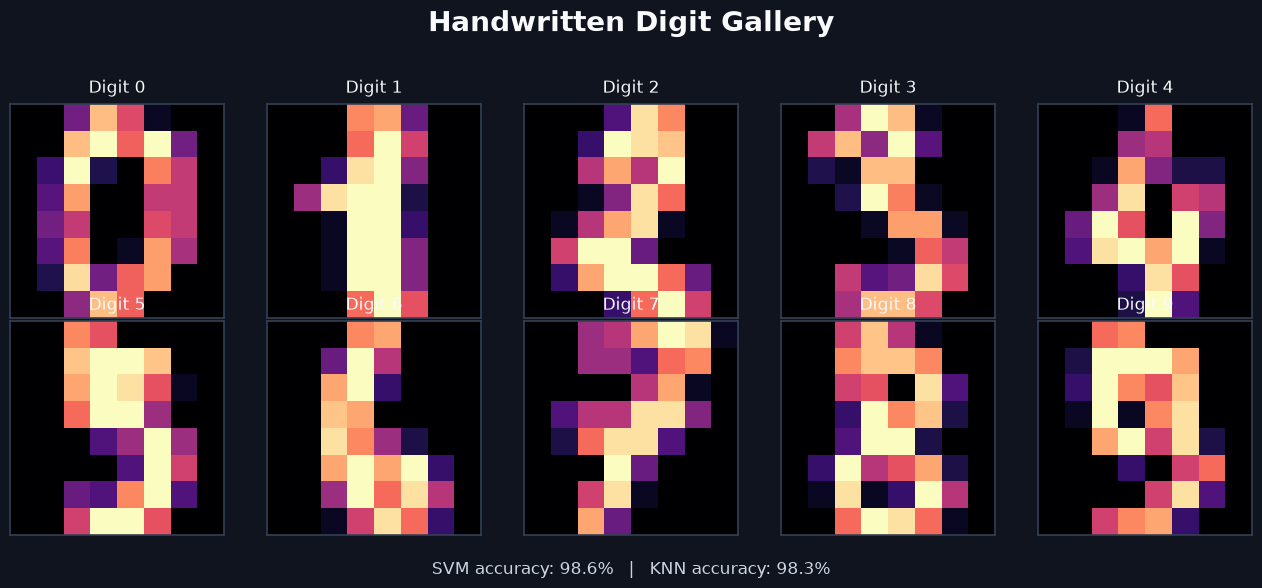

In [58]:
# ==========================================
# 6. Visualize handwritten digits
# ==========================================

plt.style.use("dark_background")

fig, axes = plt.subplots(2, 5, figsize=(13, 6), facecolor="#10141f")
fig.suptitle(
    "Handwritten Digit Gallery",
    fontsize=20,
    fontweight="bold",
    color="#f8fafc",
    y=0.98
)

for ax, image, label in zip(axes.flat, digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="magma", interpolation="nearest")
    ax.set_title(f"Digit {label}", fontsize=12, color="#f8fafc", pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("#334155")
        spine.set_linewidth(1.2)

fig.text(
    0.5,
    0.04,
    f"SVM accuracy: {svm_accuracy:.1%}   |   KNN accuracy: {knn_accuracy:.1%}",
    ha="center",
    fontsize=12,
    color="#cbd5e1"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

In [34]:
# ==========================================
# 7. Test one image
# ==========================================

sample = X_test.iloc[[0]]

actual = y_test.iloc[0]

svm_prediction = svm_model.predict(sample)[0]

knn_prediction = knn_model.predict(sample)[0]

print("\n====================")
print("SINGLE IMAGE TEST")
print("====================")

print("Actual digit:", actual)

print("SVM prediction:", svm_prediction)

print("KNN prediction:", knn_prediction)


SINGLE IMAGE TEST
Actual digit: 6
SVM prediction: 6
KNN prediction: 6
